# Summary of text descriptives

In [1]:
# import modules
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# import descriptives
descriptives = pd.read_csv("data/corpus_descriptives.csv")

### Plot descriptives

In [5]:
def plot_descriptives(df: pd.DataFrame, parameter: str, save_fig: bool = True):
    if f"{parameter}_mean" in df.columns:
        df = df.sort_values(by=f"{parameter}_mean")
    else:
        df = df.sort_values(by=parameter)

    df["x"] = range(len(df.index))
    _ = plt.figure(figsize=(20, 9))

    groups = df.groupby("text_type")

    for name, group in groups:
        x = group["x"]

        if f"{parameter}_mean" in df.columns:
            y = group[f"{parameter}_mean"]
            y_std = group[f"{parameter}_std"]
            plt.errorbar(x, y, yerr=y_std, fmt="o", label=name, markersize=10)
        else:
            y = group[parameter]
            plt.errorbar(x, y, fmt="o", label=name, markersize=10)
        plt.ylabel(parameter)

    text_names = df["file_name"]
    plt.xticks(df["x"], text_names, rotation=90)
    plt.grid(color="grey")
    plt.legend()
    plt.show()
    if save_fig:
        plt.savefig(f"figs/{parameter}.png", bbox_inches="tight")

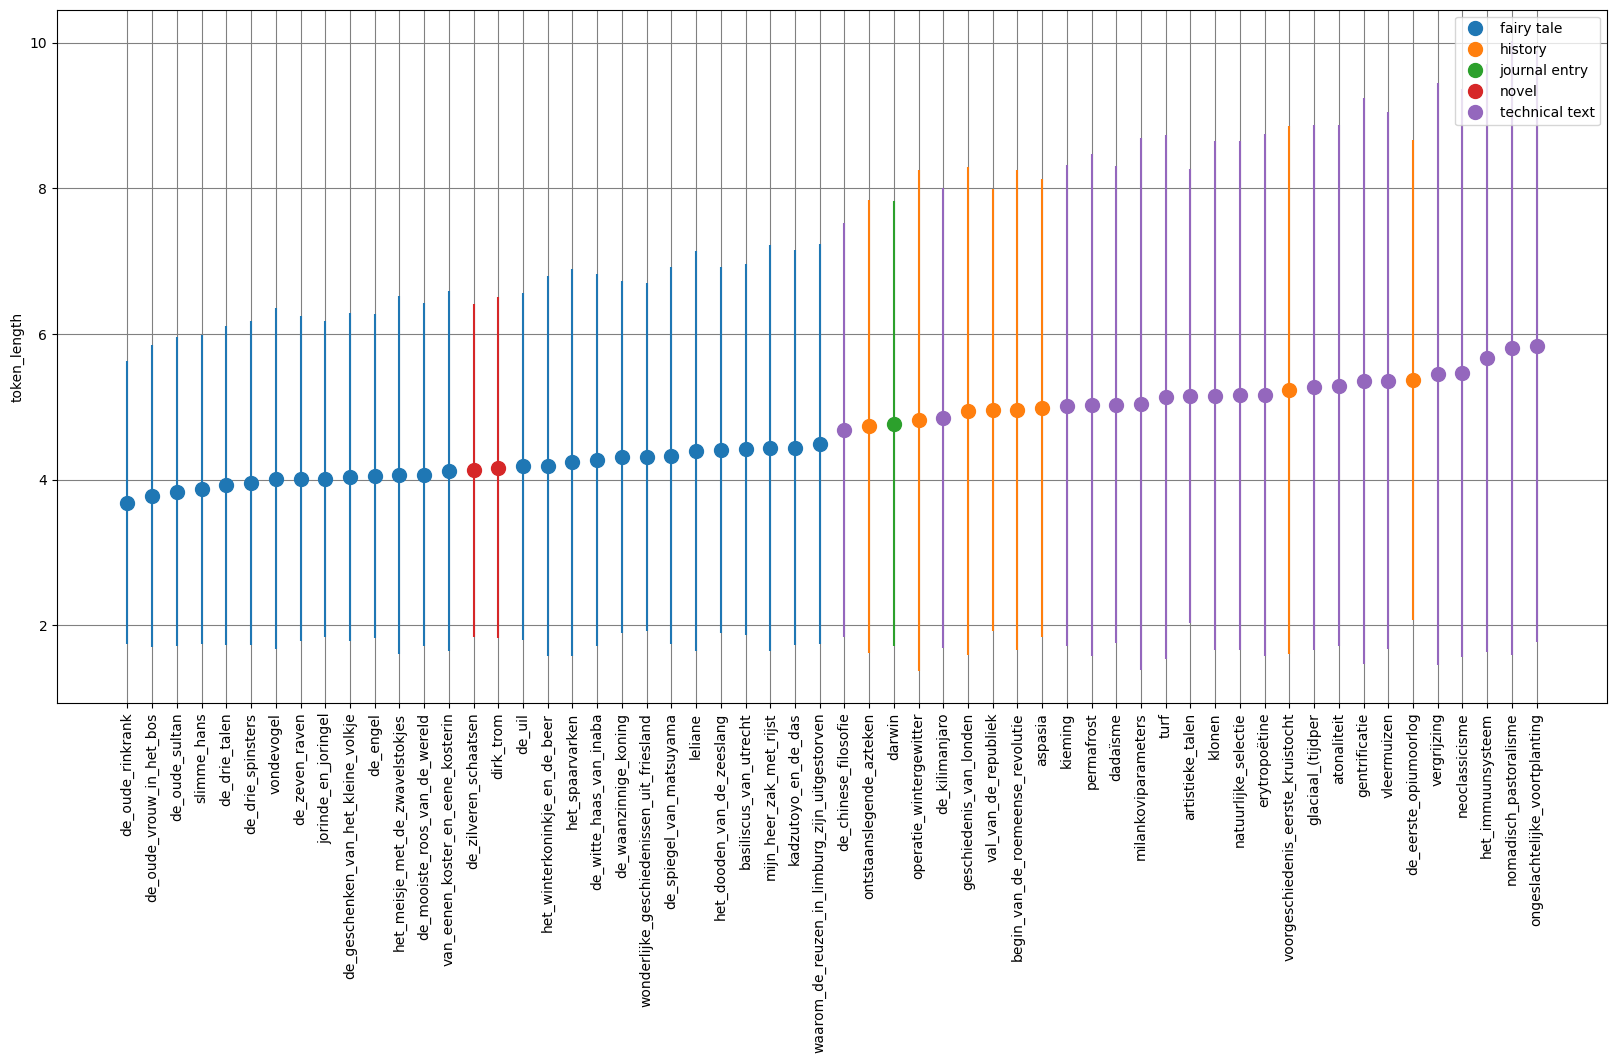

<Figure size 640x480 with 0 Axes>

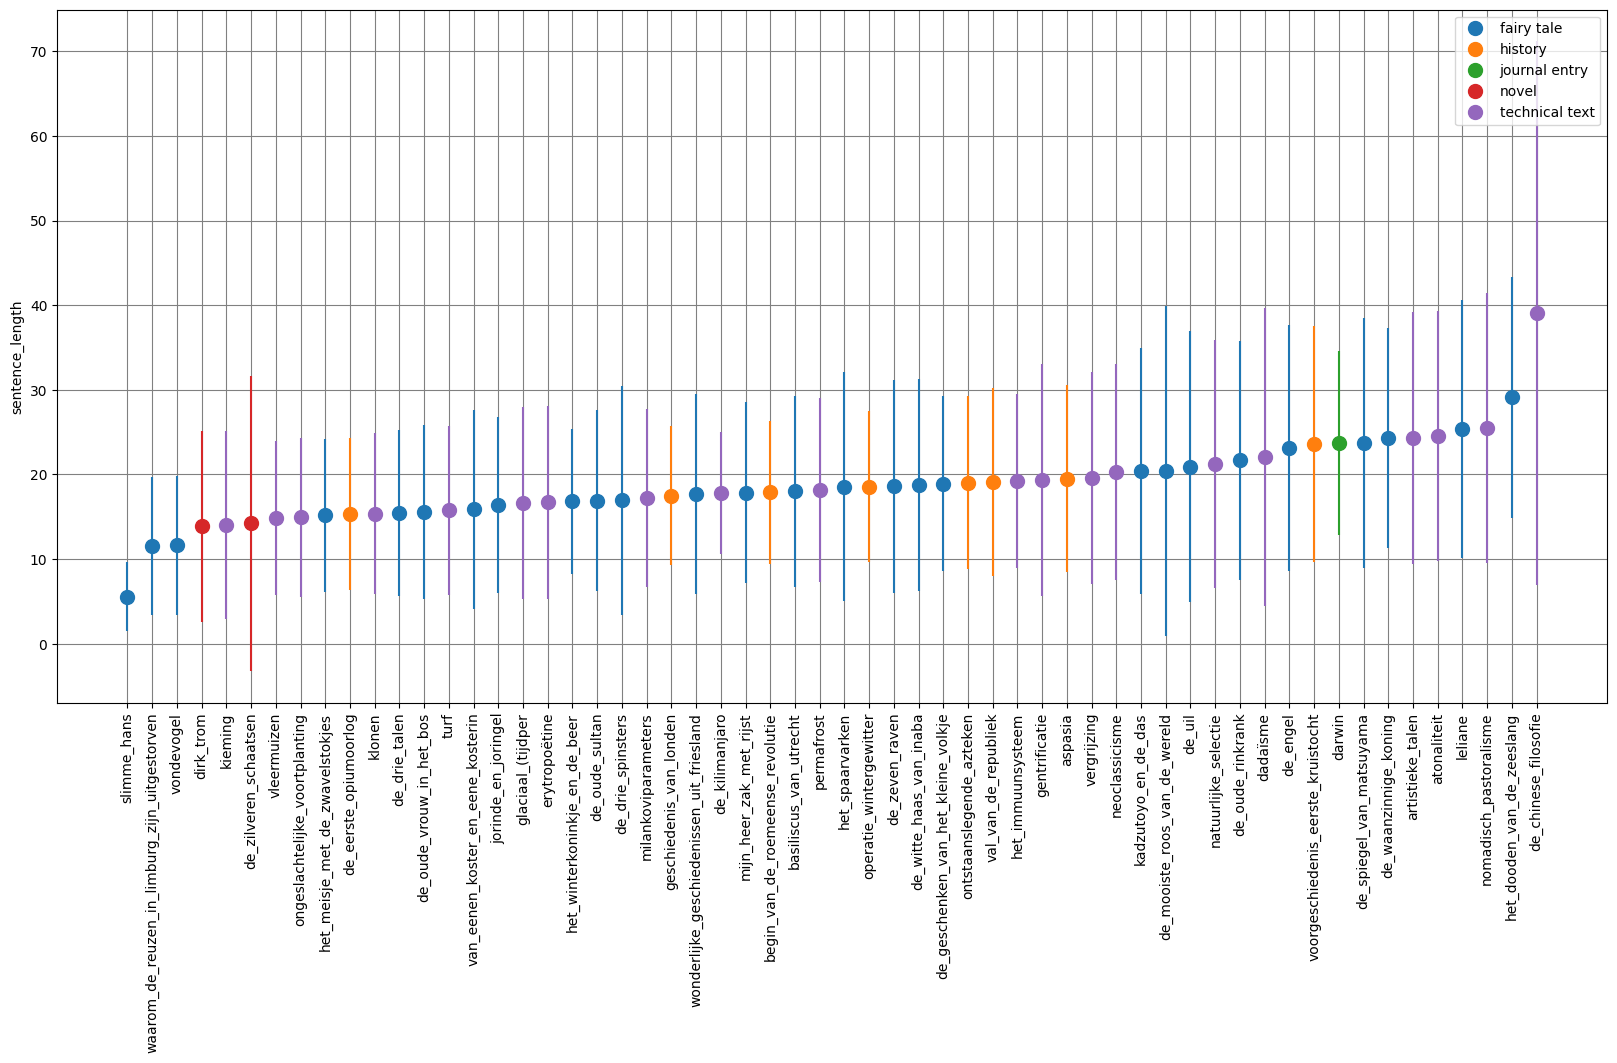

<Figure size 640x480 with 0 Axes>

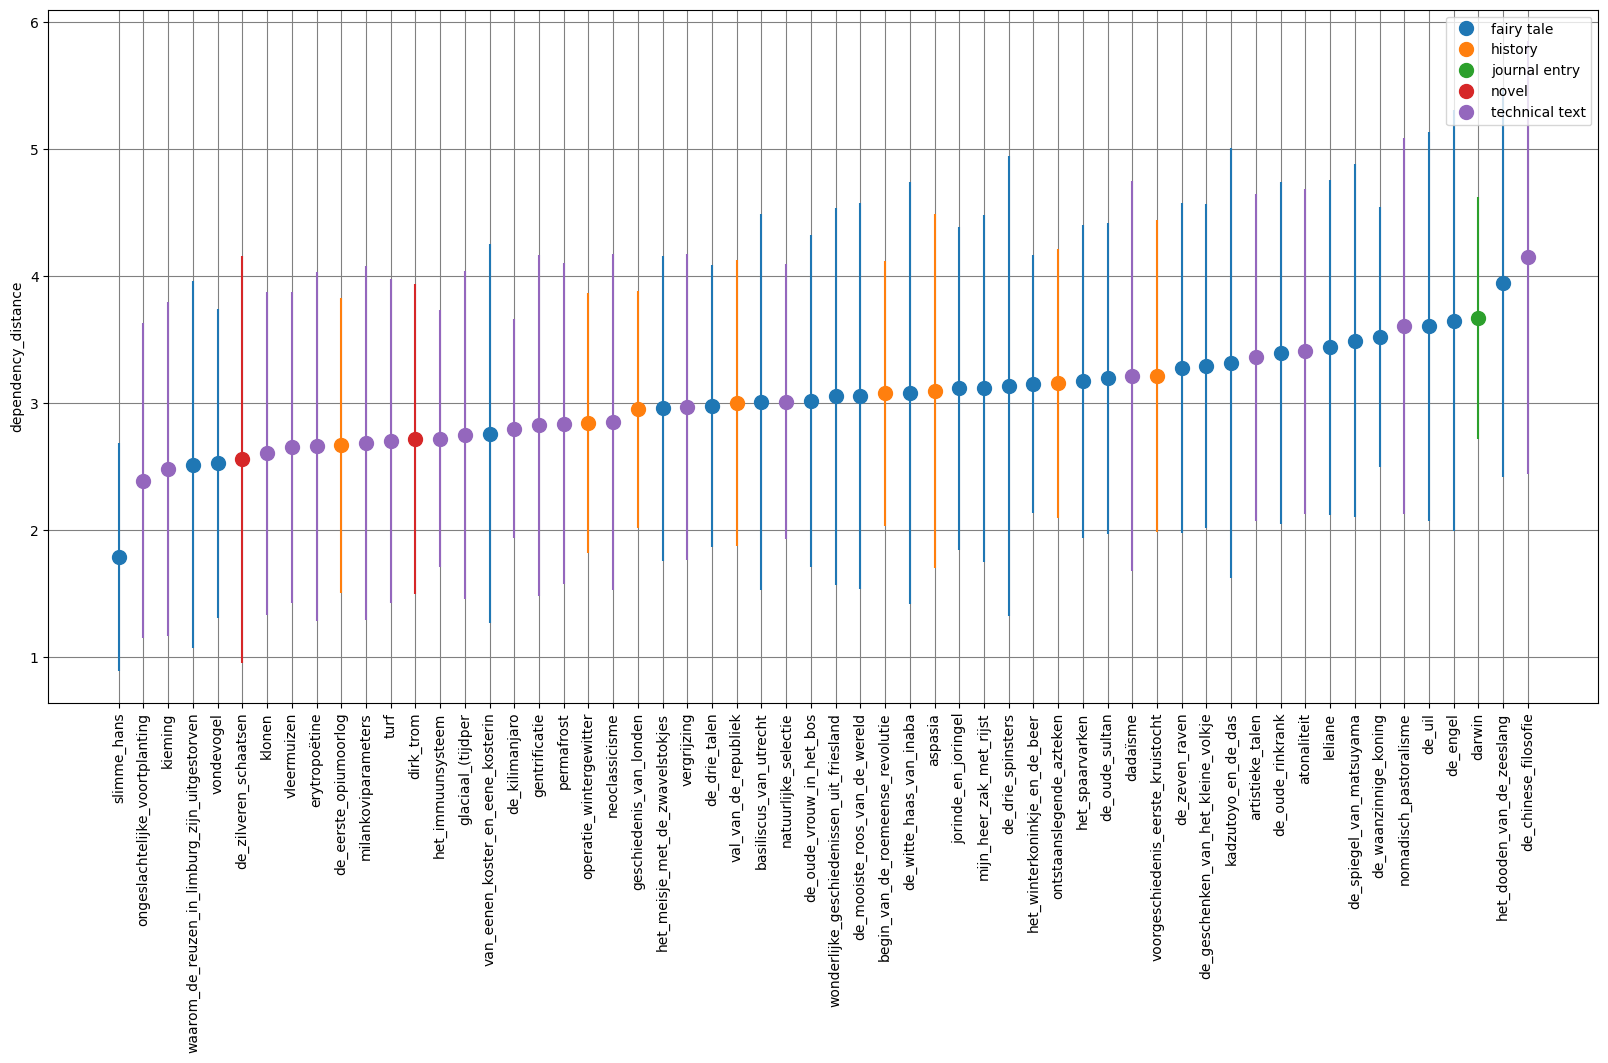

<Figure size 640x480 with 0 Axes>

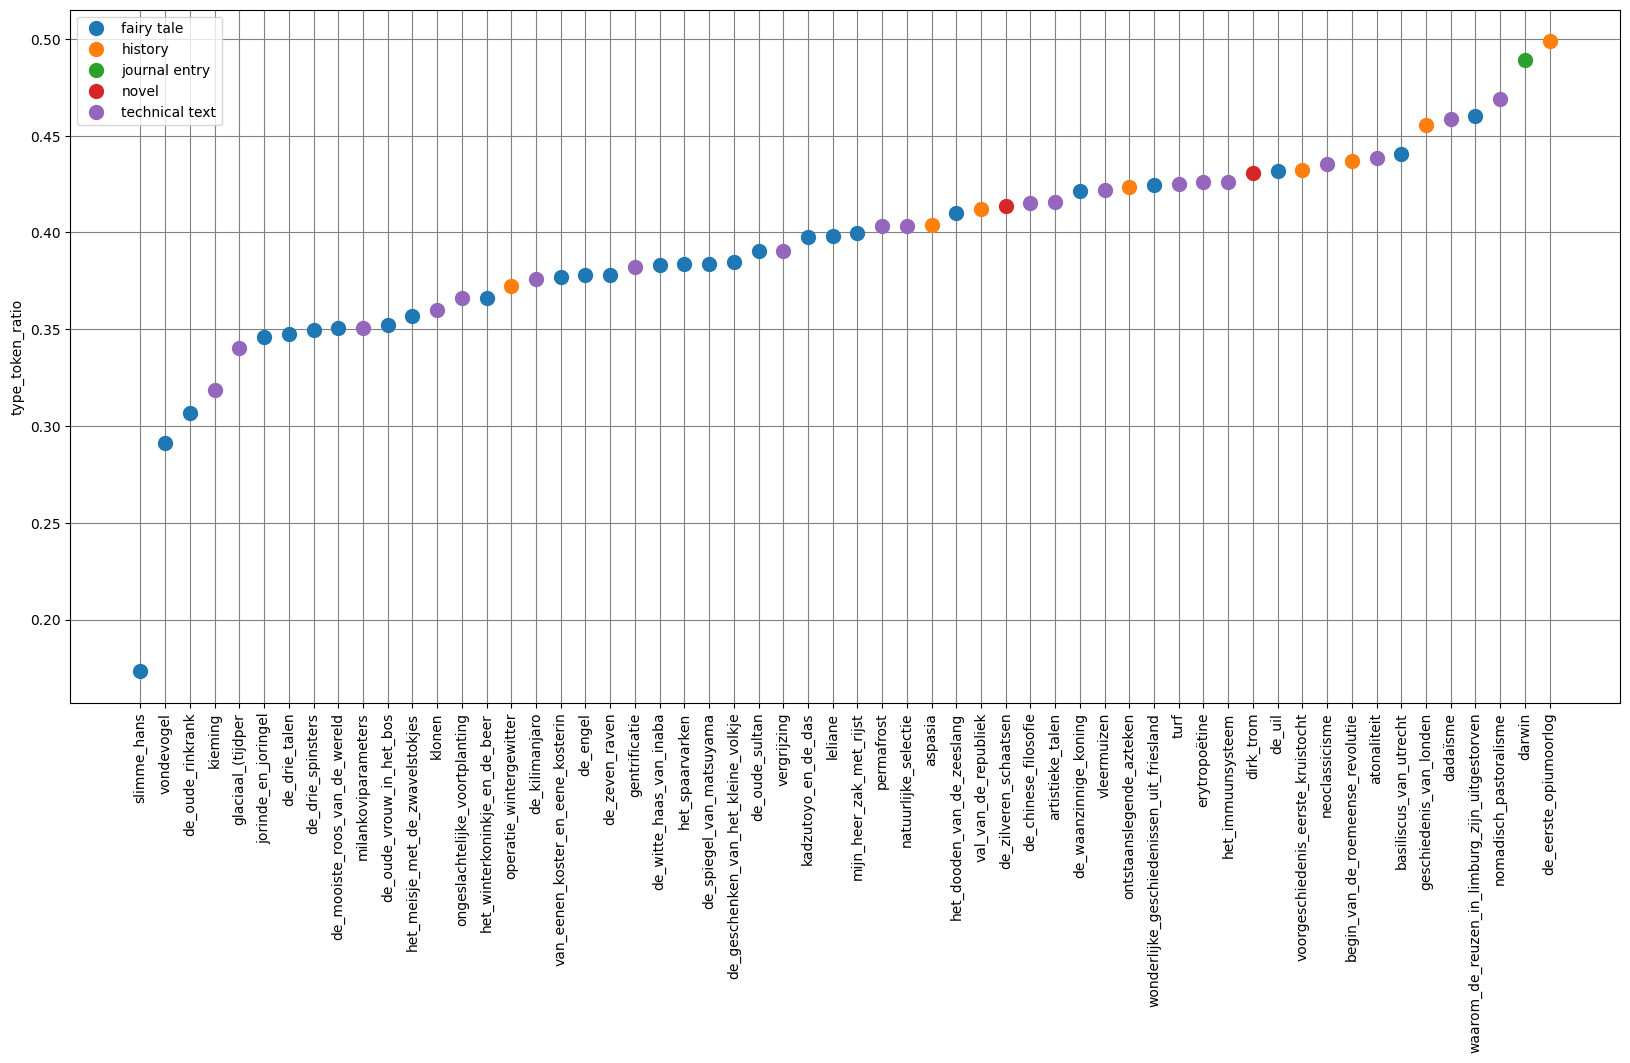

<Figure size 640x480 with 0 Axes>

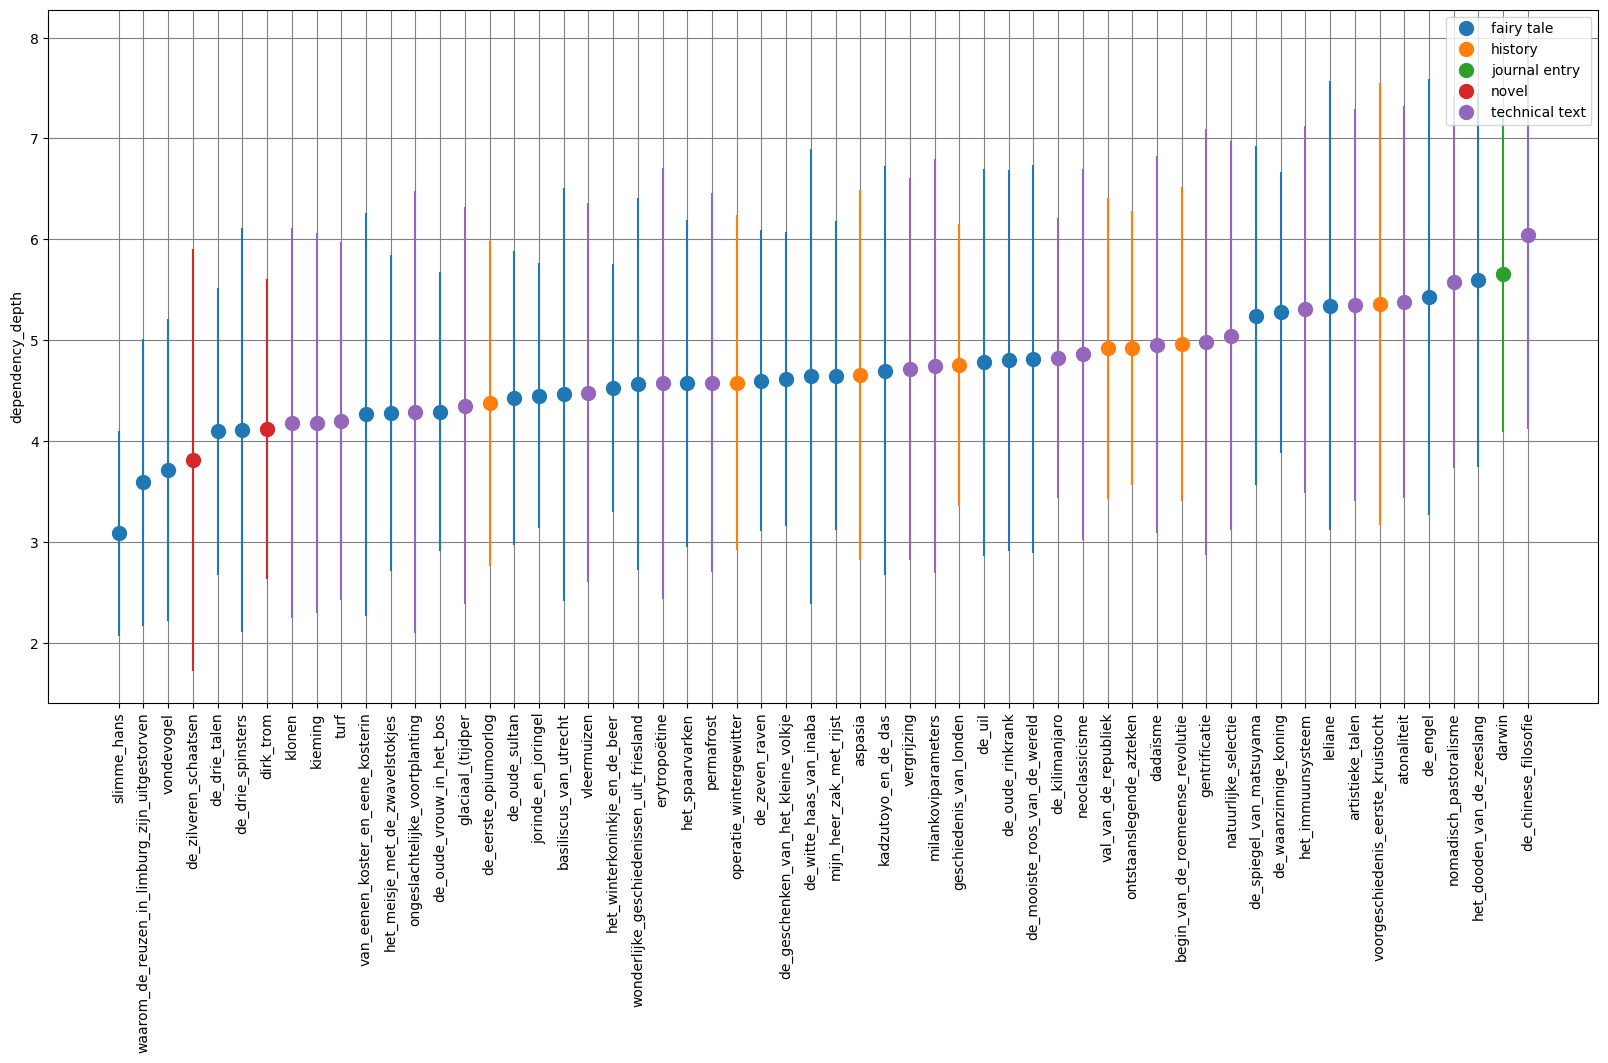

<Figure size 640x480 with 0 Axes>

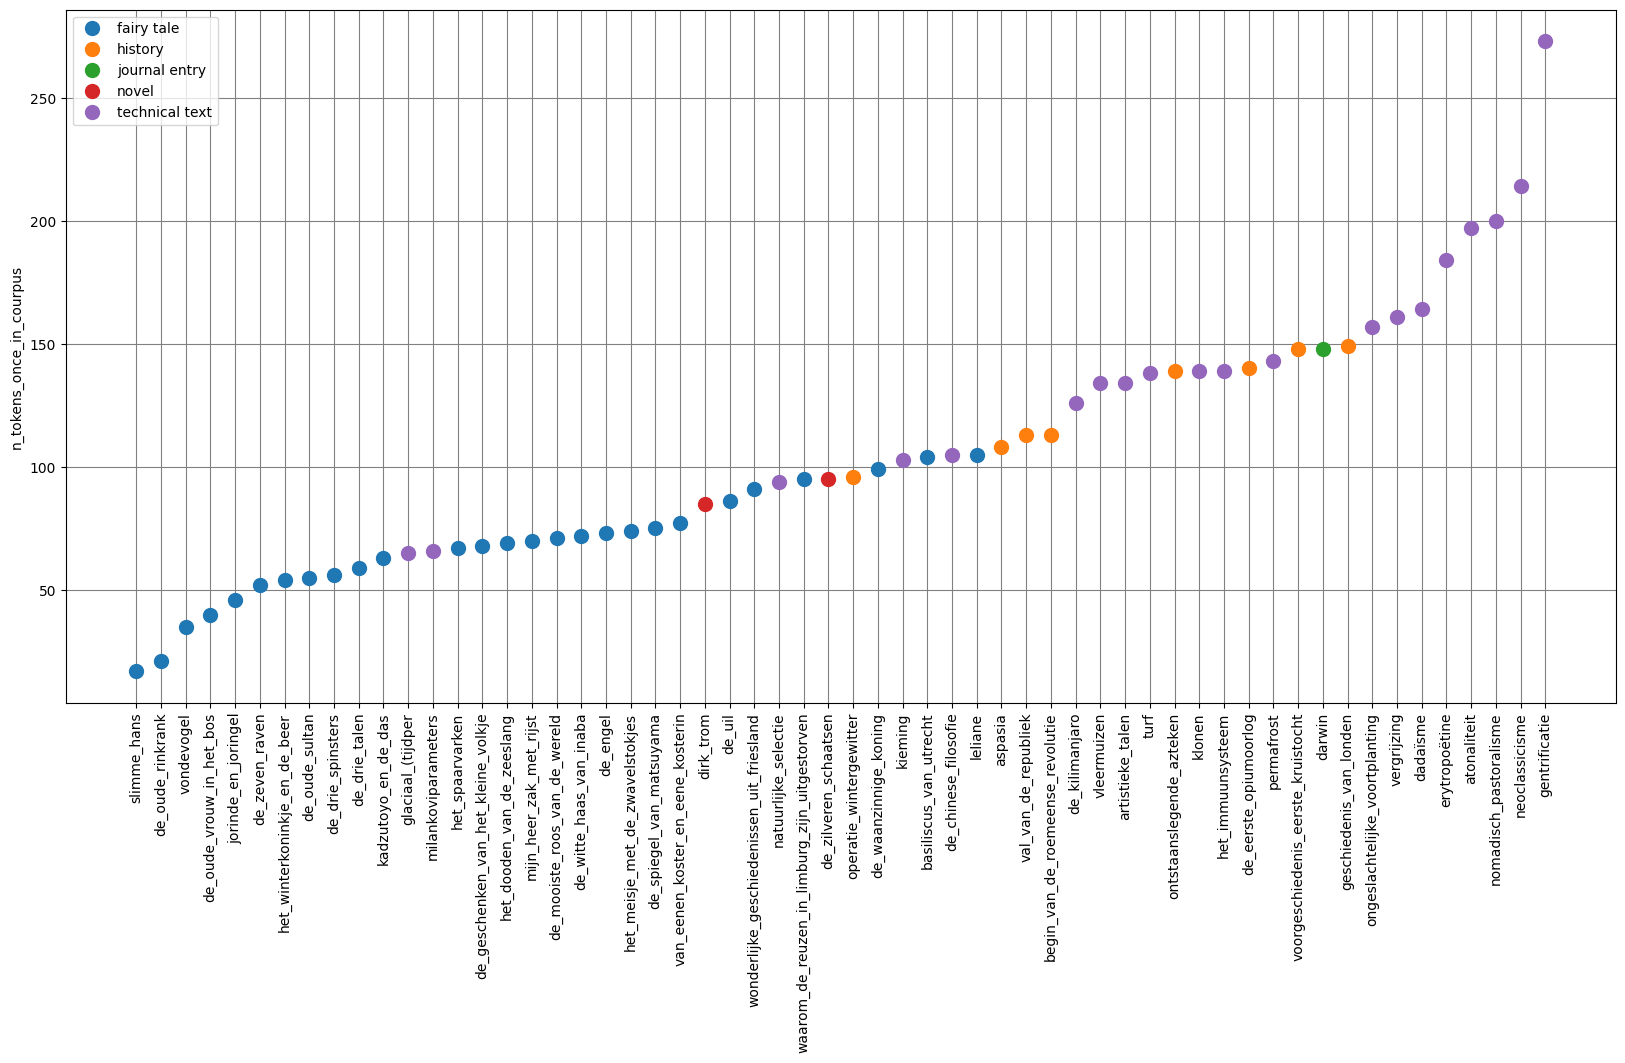

<Figure size 640x480 with 0 Axes>

In [6]:
plot_parameters = [
        "token_length",
        "sentence_length",
        "dependency_distance",
        "type_token_ratio",
        "dependency_depth",
        "n_tokens_once_in_courpus",
    ]

for parameter in plot_parameters:
    plot_descriptives(descriptives, parameter)